# Dysenet Classifier for dysarthric severity classification

Import the necessary packages

In [1]:
import sys
import os
from os import path
import glob
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from tqdm import tqdm
import numpy as np
import matplotlib
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv1D
from tensorflow.keras.layers import LeakyReLU, BatchNormalization, Flatten, MaxPooling1D, Input
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

Load the psycho-acoustic features and labels

In [2]:
from google.colab import drive
drive.mount('/content/drive')
dysr_feats_path = '/content/drive/My Drive/Research/Wav_headMic_dysr_artdynamic_feats.npy'
cln_feats_path= '/content/drive/My Drive/Research/Wav_headMic_clean_artdynamic_feats.npy'
dysr_feats_lbl_path='/content/drive/My Drive/Research/Wav_headMic_sev_dysr_lbl.npy'
cln_feats_lbl_path='/content/drive/My Drive/Research/Wav_headMic_sev_clean_lbl.npy'
cln_feats = np.load(cln_feats_path)
dysr_feats = np.load(dysr_feats_path)
cln_feats_lbl = np.load(cln_feats_lbl_path)
dysr_feats_lbl = np.load(dysr_feats_lbl_path)
print(cln_feats.shape)

Mounted at /content/drive
(24279, 58)


Process the data to fit for tranining

In [3]:
data_x_lst = []
data_y_lst = []
feat_len = len(dysr_feats)
print(feat_len)
j=0
for i in range(feat_len):
    data_x_lst.append(cln_feats[i,:])
    data_y_lst.append(cln_feats_lbl[i])
    data_x_lst.append(dysr_feats[i,:])
    data_y_lst.append(dysr_feats_lbl[i])
data_x = np.array(data_x_lst)
data_y = np.array(data_y_lst)
print(data_x.shape, data_y.shape)
data_y_onehot = keras.utils.to_categorical(data_y, num_classes=4)

15635
(31270, 58) (31270,)


Define the Dysenet model

In [4]:
def dysenet_model():
  out_dim = 4 #number of classes
  inputs = Input((58, 1))
  x = Conv1D(64, 3, strides=1, padding='valid')(inputs)
  x = BatchNormalization(momentum=0.05)(x)
  x = LeakyReLU(alpha=0.2)(x)
  x = MaxPooling1D(pool_size=2)(x)

  x = Conv1D(64, 3, strides=1, padding='valid')(x)
  x = BatchNormalization(momentum=0.05)(x)
  x = LeakyReLU(alpha=0.2)(x)
  x = MaxPooling1D(pool_size=2)(x)

  x = Conv1D(128, 3, strides=1, padding='valid')(x)
  x = BatchNormalization(momentum=0.05)(x)
  x = LeakyReLU(alpha=0.2)(x)
  x = MaxPooling1D(pool_size=2)(x)

  x = Conv1D(128, 3, strides=1, padding='valid')(x)
  x = BatchNormalization(momentum=0.05)(x)
  x = LeakyReLU(alpha=0.2)(x)
  x = MaxPooling1D(pool_size=2)(x)

  x = Flatten()(x)

  x = Dense(256)(x)
  x = BatchNormalization(momentum=0.05, epsilon=1e-5)(x)
  x = LeakyReLU(alpha=0.2)(x)

  x = Dense(256)(x)
  x = BatchNormalization(momentum=0.05, epsilon=1e-5)(x)
  x = LeakyReLU(alpha=0.2)(x)

  prediction = Dense(out_dim, activation='softmax')(x)
  dysenet_model = tf.keras.models.Model(inputs=inputs, outputs=prediction)
  dysenet_model.compile(optimizer=keras.optimizers.Adam(1e-4),loss="categorical_crossentropy",metrics=["accuracy"])

  dysenet_model.summary()
  return dysenet_model

Train the dysenet model with the dataset

In [5]:
import pandas as pd
BATCH_SIZE = 25
EPOCHS = 500
with tf.device('/device:GPU:0'):
  model = dysenet_model()
  model_name = "dysarthric-dysenet-{}.keras".format("psychoacoustic")
  history_cnn = model.fit(data_x,data_y_onehot,batch_size=BATCH_SIZE,validation_split=0.2,epochs=EPOCHS,shuffle=True)
  history_df = pd.DataFrame(history_cnn.history)
  model_path = '/content/drive/My Drive/Research/'+model_name
  history_path='/content/drive/My Drive/Research/history_dysenet.csv'
  history_df.to_csv(history_path, index_label='epoch')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 58, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 56, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 56, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 56, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 26, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 11, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 3, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 190,020 (742.27 KB)

 Trainable params: 188,228 (735.27 KB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/500
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.6118 - loss: 0.9170 - val_accuracy: 0.1879 - val_loss: 2.6742
Epoch 2/500
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6922 - loss: 0.7340 - val_accuracy: 0.2779 - val_loss: 2.8140
Epoch 3/500
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7191 - loss: 0.6709 - val_accuracy: 0.2408 - val_loss: 3.4298
Epoch 4/500
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7414 - loss: 0.6260 - val_accuracy: 0.1573 - val_loss: 3.7304
Epoch 5/500
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7601 - loss: 0.5858 - val_accuracy: 0.2611 - val_loss: 3.0852
Epoch 6/500
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7746 - loss: 0.5505 - val_accuracy: 0.2239 - val_loss: 3.2270
Epoch 7/500
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7868 - loss: 0.5284 - val_accuracy: 0.2210 - val_loss: 3.6308
Epoch 8/500
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7979 - loss: 

Predict the results

978/978 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
31270 31270


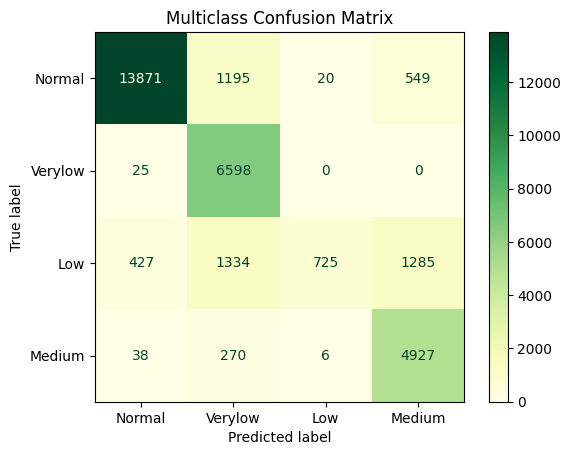

In [7]:
model_name = "dysarthric-dysenet-{}.keras".format("psychoacoustic")
model_path =  '/content/drive/My Drive/Research/'+model_name
mdl = model
classes = ['Normal','Verylow','Low','Medium']
y_pred = []
res = mdl.predict(data_x)
for i  in range(len(res)):
  #print(np.argmax(res[i]), data_y[i])
  y_pred.append(np.argmax(res[i]))

y_pred_arr = np.array(y_pred)
y_act = data_y
print(len(y_pred_arr), len(y_act))
cm = confusion_matrix(y_act, y_pred_arr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.YlGn) # Use a blue colormap
plt.title('Multiclass Confusion Matrix')
plt.show()